# 03 - Benchmark models

**Part 2 and Part 3 of the assignment.** Defines the forecasting problem precisely, then fits the five benchmark forecasts (mean, naive, daily seasonal naive, weekly seasonal naive, drift) using a **rolling-origin, 24-hour-horizon backtest** across the 14-day test period.

## Forecasting problem definition (Part 2)

| | |
|---|---|
| **Target variable** | `Appliances` - hourly-mean appliance energy use (Wh) |
| **Forecast horizon** | 24 hours |
| **Train / test split** | Final 14 days (336 hourly rows) held out as test; everything before that is training data |
| **Evaluation protocol** | Rolling-origin: 14 separate 24-hour-ahead forecasts, one per test day, each using an expanding training window |
| **Metrics** | MAE, RMSE, MASE (scaled to the in-sample daily seasonal-naive error), Bias |

We use a rolling-origin backtest rather than a single 336-step-ahead forecast because the brief specifies a *24-hour* forecast horizon; re-forecasting once per day across the test fortnight satisfies that literally while still covering the whole held-out period, and it's how a real deployed forecaster would actually be operated (predict tomorrow, observe it, predict the next day, ...).

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
hourly = D.load_hourly_data()
y = hourly[config.TARGET]

train = y.iloc[:-config.TEST_STEPS]
test = y.iloc[-config.TEST_STEPS:]

print('Train:', train.index.min(), 'to', train.index.max(), f'({len(train)} rows)')
print('Test: ', test.index.min(), 'to', test.index.max(), f'({len(test)} rows)')
print('Rolling-origin windows:', config.N_ROLLING_ORIGINS, 'x', config.HORIZON, 'hours')

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv
Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00 (2954 rows)
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00 (336 rows)
Rolling-origin windows: 14 x 24 hours


## Fit all five benchmarks

In [3]:
forecasts = B.run_all_benchmarks(y)
for name, fc in forecasts.items():
    print(f'{name:24s} {len(fc)} predictions')

mean                     336 predictions
naive                    336 predictions
seasonal_naive_daily     336 predictions
seasonal_naive_weekly    336 predictions
drift                    336 predictions


## Evaluate

In [4]:
results = [E.evaluate_forecast(name, test, fc, train) for name, fc in forecasts.items()]
benchmark_metrics = E.summarise_metrics(results)
benchmark_metrics

,model,n_obs,MAE,RMSE,MASE,Bias
0,seasonal_naive_weekly,336,43.457341,81.408880,0.813446,-13.159722
1,seasonal_naive_daily,336,48.308532,85.564719,0.904252,1.750992
2,mean,336,50.258092,74.938304,0.940744,-3.286762
3,naive,336,85.550595,110.389709,1.601358,50.977183
4,drift,336,85.802089,110.679190,1.606066,51.367922


## Plot forecasts against the actual test data

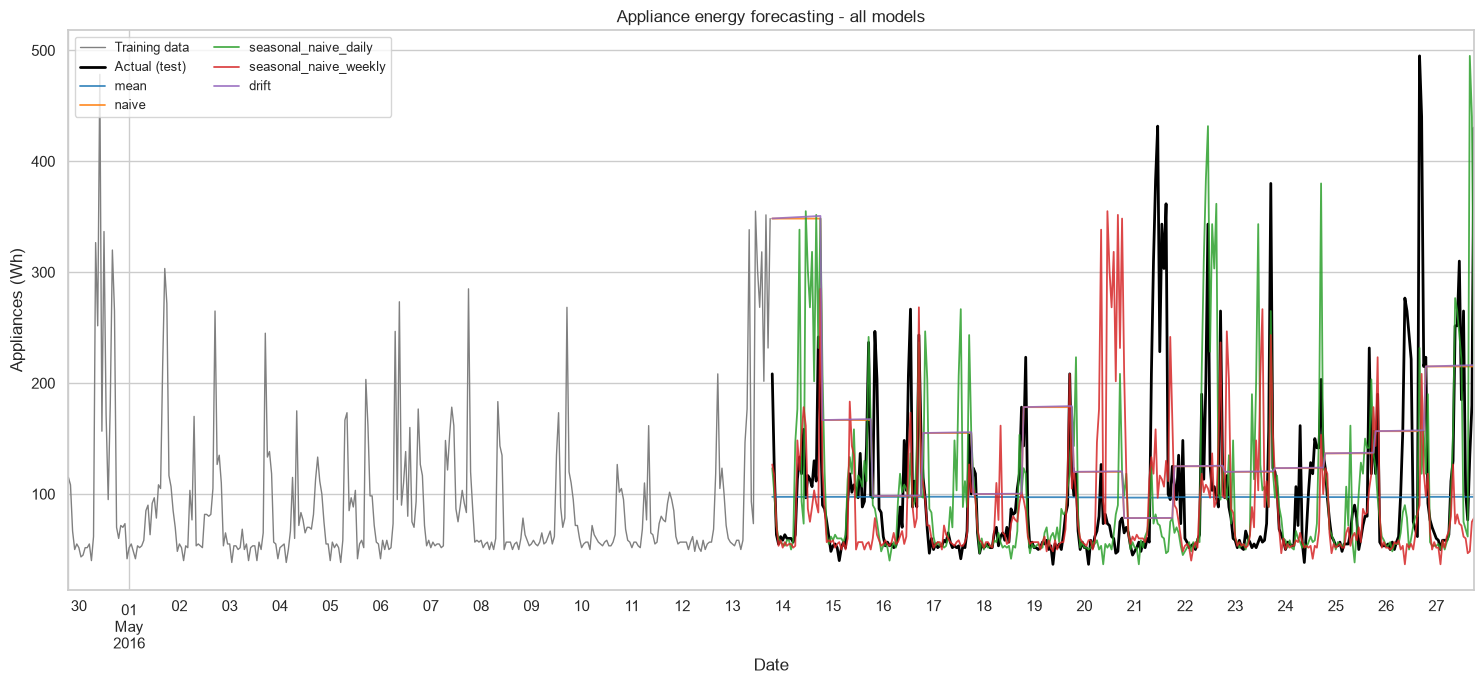

In [5]:
forecast_df = pd.DataFrame({'actual': test, **forecasts})
P.plot_forecast_vs_actual(train, test, forecast_df.drop(columns='actual'))
plt.show()

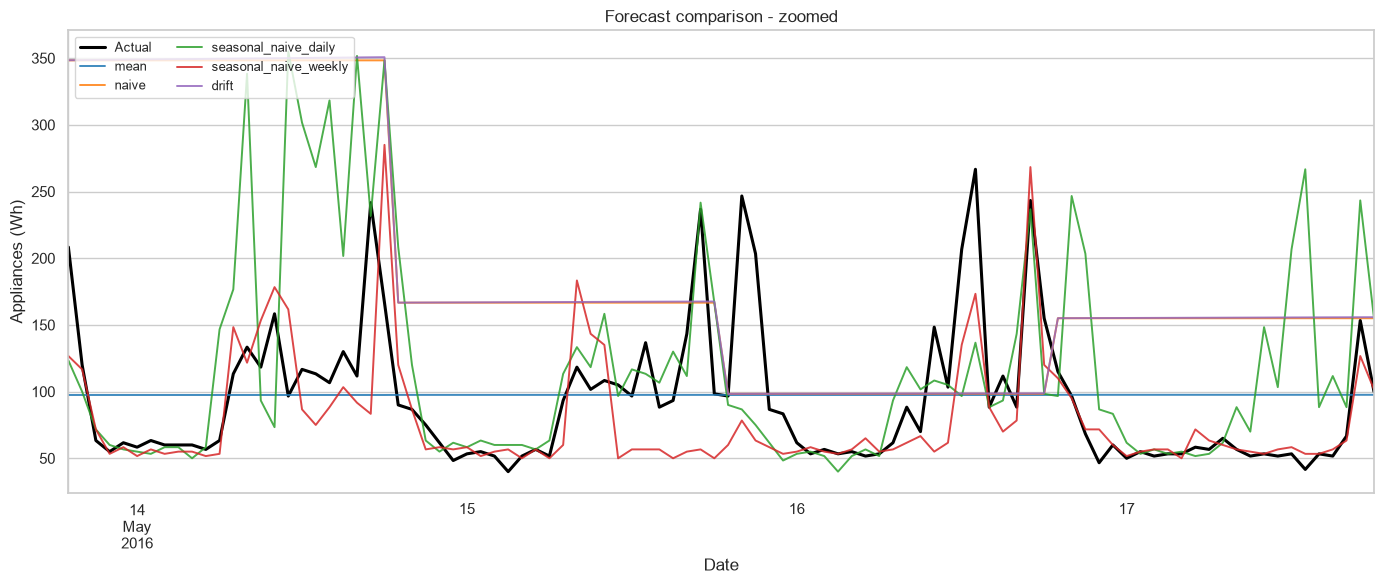

In [6]:
P.plot_forecast_zoom(test, forecast_df.drop(columns='actual'), days=4); plt.show()

### Interpretation

The ranking of the five benchmarks is itself informative about the structure of the series (this directly answers Part 9, Q1 - see `07_model_comparison.ipynb` for the full discussion):

- **Naive** and **drift** perform worst, because they assume tomorrow looks like right now (or a straight-line extrapolation of the whole training trend) - appliance use has almost no persistence at a 1-hour lag once you're forecasting 24 hours ahead, and no consistent long-run trend, so both do badly.
- **Mean** is a surprisingly strong baseline for a series without a trend, but it throws away all of the daily/weekly structure visible in the EDA notebook.
- **Seasonal naive (daily and weekly)** perform best, because they directly encode the strongest structure the series has: usage repeats on a daily and weekly cycle. Weekly typically edges out daily, since it also captures the weekday/weekend shift that a same-hour-yesterday copy misses.

This sets the bar that SARIMAX (04), the feature-based model (05), and the foundation model (06) all need to clear to be worth their added complexity.